In [15]:
clusters.sum(axis=0)

array([ 583, 1031,  333,  131])

Embeddings : (2078, 32)
Train/Val/Test split: 1246 / 415 / 417
Fit set  : (1661, 32)
Test set : (417, 32)
Observed event rate (fit) : 0.172
Observed event rate (test): 0.187
Median follow-up (fit)    : 3597.00
Median follow-up (test)   : 3548.00


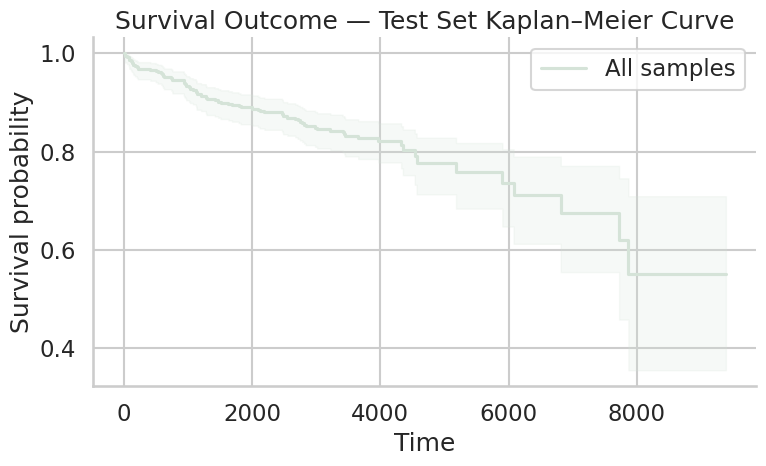

Cox PH                C-index=0.5306  t=0.08s
Penalized Cox PH      C-index=0.5463  t=0.76s


,Concordance Index,Time (s)
Model,,
Penalized Cox PH,0.5463,0.7560
Cox PH,0.5306,0.0840


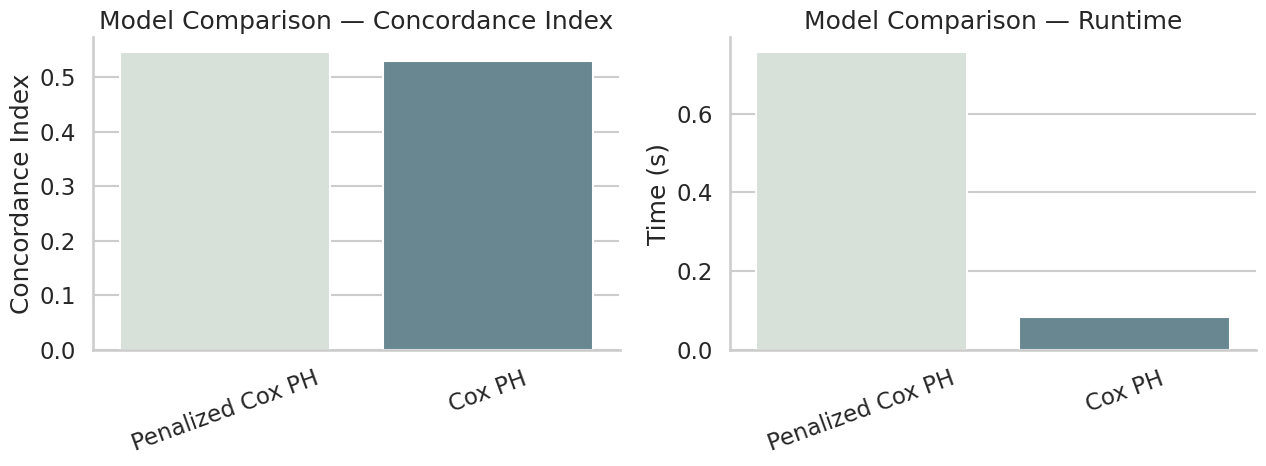


── Label: CAD ──


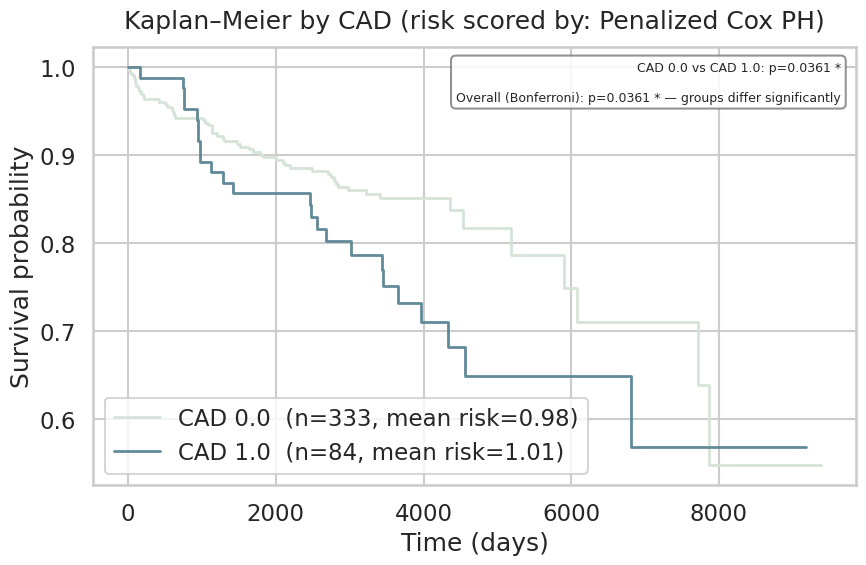


Pairwise log-rank tests:
Group A      Group B       Test stat    p-value    Sig
-------------------------------------------------------
0.0          1.0              4.3930    0.03609      *

Bonferroni-corrected minimum p: 0.03609  (significant at α=0.05)

── Label: CKD ──


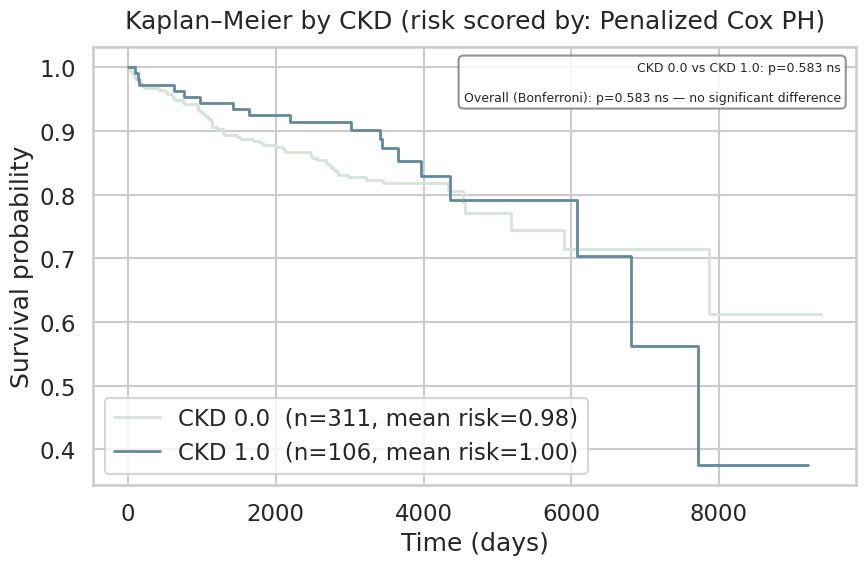


Pairwise log-rank tests:
Group A      Group B       Test stat    p-value    Sig
-------------------------------------------------------
0.0          1.0              0.3016     0.5829       

Bonferroni-corrected minimum p: 0.5829  (not significant at α=0.05)

── Label: DMT2 ──


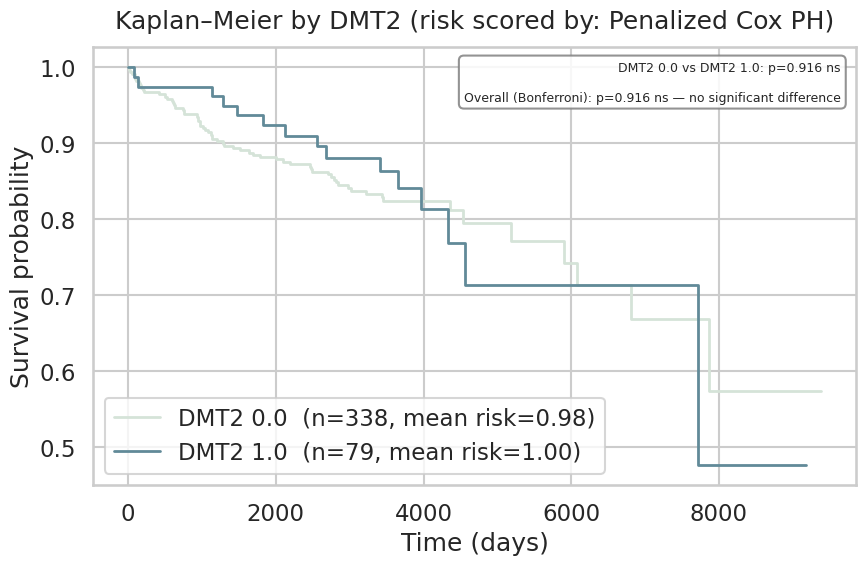


Pairwise log-rank tests:
Group A      Group B       Test stat    p-value    Sig
-------------------------------------------------------
0.0          1.0              0.0111      0.916       

Bonferroni-corrected minimum p: 0.916  (not significant at α=0.05)

── Label: Healthy ──


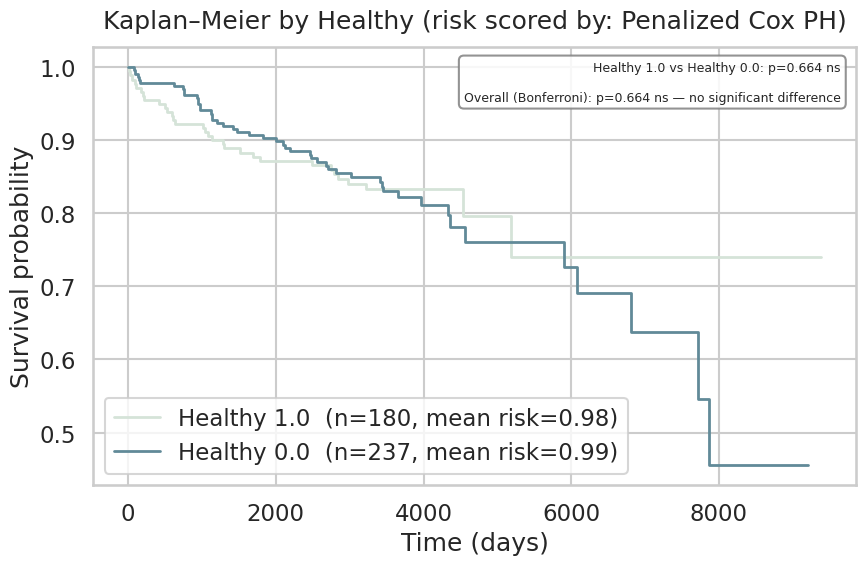


Pairwise log-rank tests:
Group A      Group B       Test stat    p-value    Sig
-------------------------------------------------------
1.0          0.0              0.1884     0.6643       

Bonferroni-corrected minimum p: 0.6643  (not significant at α=0.05)

── Label: OST ──


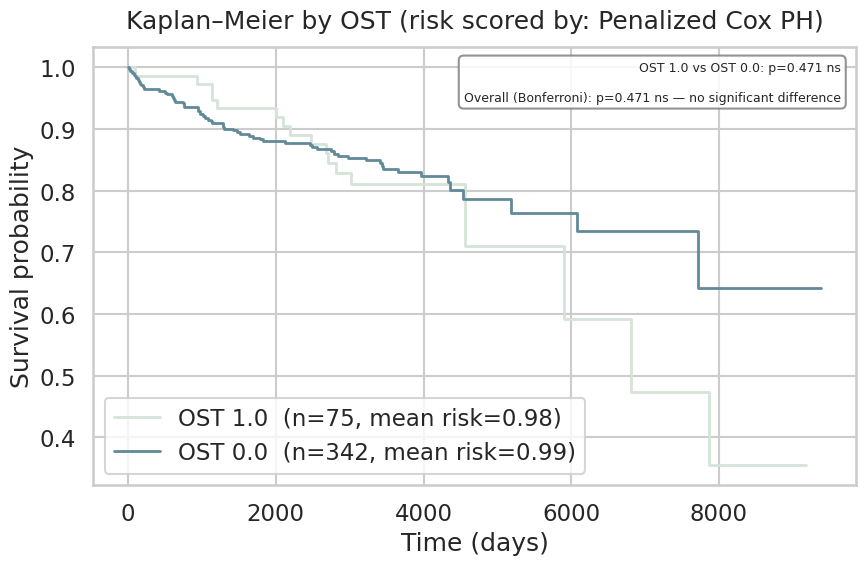


Pairwise log-rank tests:
Group A      Group B       Test stat    p-value    Sig
-------------------------------------------------------
1.0          0.0              0.5189     0.4713       

Bonferroni-corrected minimum p: 0.4713  (not significant at α=0.05)


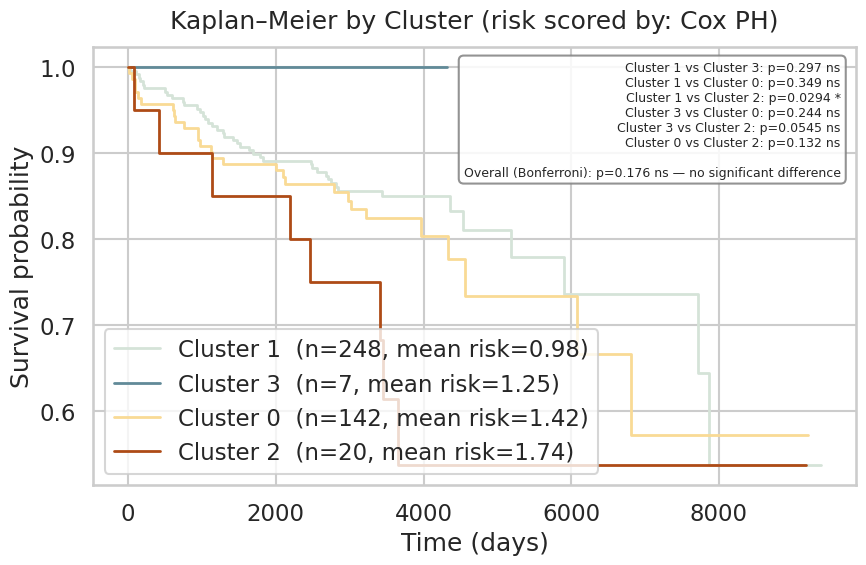


Pairwise log-rank tests:
Group A      Group B       Test stat    p-value    Sig
-------------------------------------------------------
1            3                1.0894     0.2966       
1            0                0.8782     0.3487       
1            2                4.7439     0.0294      *
3            0                1.3547     0.2445       
3            2                3.6958    0.05455       
0            2                2.2687      0.132       

Bonferroni-corrected minimum p: 0.1764  (not significant at α=0.05)


In [11]:
# ============================================================
# Survival Analysis on GNN Embeddings 
# Seaborn + palettable (wesanderson.Darjeeling2_5)
# ============================================================

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

from lifelines import CoxPHFitter
from palettable.wesanderson import Darjeeling2_5

import sys
sys.path.insert(0, "./../MAIN/")
from network_functions import load_graph, node_labels
from applications import plot_model_comparison, plot_km_by_group, plot_overall_km, eval_survival_model, make_survival_targets_from_death_df

# ── Config ────────────────────────────────────────────────────────────────────
PKL_PATH        = "/work/gr-fe/bryan/data/SHCS/03_final/mogsage_gnn_embeddings_0.2.pkl"
DEATH_PATH      = "/work/gr-fe/bryan/data/SHCS/02_processed/death.pkl"
GRAPH_PATH      = "/work/gr-fe/bryan/data/SHCS/Networks/KGshcs_psn.gpickle"
CLUSTER_PATH     = "/work/gr-fe/bryan/data/SHCS/03_final/mogsage_cluster_membership.npy"
RANDOM_STATE    = 42

# ── Plot style ────────────────────────────────────────────────────────────────
PALETTE = Darjeeling2_5.mpl_colors
sns.set_theme(style="whitegrid", context="talk", palette=PALETTE)

COL_1, COL_2, COL_3, COL_4, COL_5 = PALETTE

# ── 1. Load embeddings and death data ─────────────────────────────────────────
with open(PKL_PATH, "rb") as f:
    blob = pickle.load(f)

H         = blob["embeddings"]
train_idx = blob["train_idx"]
val_idx   = blob["val_idx"]
test_idx  = blob["test_idx"]

print(f"Embeddings : {H.shape}")
print(f"Train/Val/Test split: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

with open(DEATH_PATH, "rb") as f:
    death = pickle.load(f)

g = load_graph(GRAPH_PATH, "PSN")
death = death.set_index("ID").loc[sorted(set(g.nodes))].reset_index()

# ── 2. Build train / test sets ───────────────────────────────────────────────
fit_idx = np.concatenate([train_idx, val_idx])
X_train = H[fit_idx]
X_test  = H[test_idx]

print(f"Fit set  : {X_train.shape}")
print(f"Test set : {X_test.shape}")

# ── 3. Build survival targets from death dataframe ───────────────────────────
dur_all, evt_all, risk_all = make_survival_targets_from_death_df(
    H,
    death_df=death,
    death_col="DEATH_DATE",
    sample_col="SAMPLE_DATE",
    censor_strategy="global_max",
    censor_date="2026-04-01",   # only used if censor_strategy="given"
)

dur_train, evt_train = dur_all[fit_idx], evt_all[fit_idx]
dur_test,  evt_test  = dur_all[test_idx], evt_all[test_idx]

print(f"Observed event rate (fit) : {evt_train.mean():.3f}")
print(f"Observed event rate (test): {evt_test.mean():.3f}")
print(f"Median follow-up (fit)    : {np.median(dur_train):.2f}")
print(f"Median follow-up (test)   : {np.median(dur_test):.2f}")

# ── 4. Build survival DataFrames ──────────────────────────────────────────────
feature_cols = [f"emb_{i}" for i in range(H.shape[1])]

df_train = pd.DataFrame(X_train, columns=feature_cols)
df_train["time"]  = dur_train
df_train["event"] = evt_train

df_test = pd.DataFrame(X_test, columns=feature_cols)
df_test["time"]  = dur_test
df_test["event"] = evt_test

# ── 5. Plot overall KM baseline ───────────────────────────────────────────────
plot_overall_km(
    durations=dur_test,
    events=evt_test,
    title="Survival Outcome — Test Set Kaplan–Meier Curve",
    COL=COL_1,
)

# ── 6. Fit survival models ────────────────────────────────────────────────────
survival_models = {
    "Cox PH":           CoxPHFitter(),
    "Penalized Cox PH": CoxPHFitter(penalizer=0.1, l1_ratio=0.5),
}

results = []

for name, mdl in survival_models.items():
    pred_type = "median" if "Weibull" in name else "partial_hazard"
    out = eval_survival_model(mdl, df_train, df_test, name, pred_type=pred_type)
    results.append(out)
    print(f"{name:<20s}  C-index={out['Concordance Index']:.4f}  t={out['Time (s)']:.2f}s")

# ── 7. Compare models ─────────────────────────────────────────────────────────
df_results = (
    pd.DataFrame([
        {
            "Model":             r["Model"],
            "Concordance Index": r["Concordance Index"],
            "Time (s)":          r["Time (s)"],
        }
        for r in results
    ])
    .sort_values("Concordance Index", ascending=False)
    .set_index("Model")
)

display(
    df_results.style
    .background_gradient(subset=["Concordance Index"], cmap="Greens")
    .background_gradient(subset=["Time (s)"], cmap="Blues_r")
    .format(precision=4)
    .set_caption("Survival Models on GNN Embeddings")
)

plot_model_comparison(df_results, palette=PALETTE)

# ── 8. KM curves stratified by label columns ─────────────────────────────────
y_test = blob["y"][test_idx]

for i in range(y_test.shape[1]):
    label_name = blob["label_names"][i]
    print(f"\n── Label: {label_name} ──")
    risk_scores, group_info, pw, _ = plot_km_by_group(
        results=results,
        model_name="Penalized Cox PH",
        df_test=df_test,
        durations=dur_test,
        events=evt_test,
        groups=y_test[:, i],
        group_label=label_name,
        order_by="mean_risk",
        min_group_size=5,
        palette=PALETTE,
    )

# ── 9. KM curves stratified by embedding clusters ────────────────────────────
clusters      = np.load(CLUSTER_PATH)
clusters_test = clusters[test_idx]

risk_scores, group_info, pw, fig = plot_km_by_group(
    results=results,
    model_name="Cox PH",
    df_test=df_test,
    durations=dur_test,
    events=evt_test,
    groups=clusters_test.argmax(axis=1),
    group_label="Cluster",
    order_by="mean_risk",
    min_group_size=5,
    palette=PALETTE,
)